# 01 — EDA & Sanity Checks
**Marketing A/B Testing** (Kaggle): 588,101 users; `ad` group saw real ads,
`psa` control saw public service announcements. Outcome: `converted`.

Before ANY outcome comparison: validate the experiment itself.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
from src.run_analysis import load

df = load()
print(df.shape)
df.head()

(588101, 6)


,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [2]:
sizes = df["test_group"].value_counts()
print(sizes)
print(f"split: {sizes['ad']/len(df):.2%} ad / {sizes['psa']/len(df):.2%} psa")
print("duplicate user ids:", len(df) - df['user_id'].nunique())
print("users in both groups:", (df.groupby('user_id')['test_group'].nunique() > 1).sum())

test_group
ad     564577
psa     23524
Name: count, dtype: int64
split: 96.00% ad / 4.00% psa
duplicate user ids: 0
users in both groups: 0


The split is ~96/4 **by design** — the standard ad-holdout pattern where only
a small control is shown PSAs (withholding ads from 50% of traffic would be
commercially expensive). Unbalanced ≠ broken; what must be verified is that
the split matches the *intended* allocation.

## Sample Ratio Mismatch (SRM) check
Chi-square goodness-of-fit of the observed split against the assumed 96/4
design. An SRM failure (conventionally p < 0.001) means the assignment
mechanism itself is broken — bot filtering, logging loss, redirect bugs —
and no outcome comparison downstream can be trusted.

In [3]:
from src.stats_utils import srm_check
srm = srm_check(int(sizes['ad']), int(sizes['psa']), expected_ratio=0.96)
for k, v in srm.items():
    print(f"  {k}: {v}")
print("\nNOTE: the dataset ships without its experiment spec, so 96:4 is an")
print("assumption based on the observed split and industry convention; the")
print("check demonstrates the SRM methodology on that assumption.")

  n_a: 564577
  n_b: 23524
  observed_ratio: 0.96
  expected_ratio: 0.96
  chi2: 0.0
  p_value: 0.9997876225133909
  srm_detected: False

NOTE: the dataset ships without its experiment spec, so 96:4 is an
assumption based on the observed split and industry convention; the
check demonstrates the SRM methodology on that assumption.


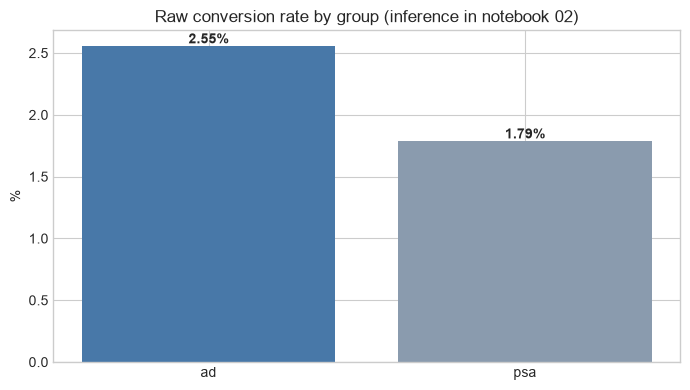

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
exp = df.groupby("test_group")["total_ads"].median()
rates = df.groupby("test_group")["converted"].mean() * 100
ax.bar(rates.index, rates.values, color=["#4878A8", "#8A9BAE"])
for i, v in enumerate(rates.values):
    ax.text(i, v, f"{v:.2f}%", ha="center", va="bottom", fontweight="bold")
ax.set_title("Raw conversion rate by group (inference in notebook 02)")
ax.set_ylabel("%")
fig.tight_layout(); fig.savefig("figures/raw_conversion_rates.png", dpi=150)
plt.show()